In [14]:
import pandas as pd

In [15]:
import polars as pl

In [16]:
!pip install openpyxl

In [17]:
df = pd.read_excel('aircraft_dataset (1).xlsx', engine='openpyxl')

In [18]:
print(df.head())

   vibration_rms  temperature     rpm  acoustic_db  risk
0            2.5         68.0  1200.0           62     0
1            3.4         76.0  1500.0           60     0
2            4.5         85.0  2000.0           68     1
3            2.6         75.0  1500.0           55     0
4            3.6         82.0  1900.0           65     1


In [19]:
df.describe

<bound method NDFrame.describe of     vibration_rms  temperature     rpm  acoustic_db  risk
0             2.5         68.0  1200.0           62     0
1             3.4         76.0  1500.0           60     0
2             4.5         85.0  2000.0           68     1
3             2.6         75.0  1500.0           55     0
4             3.6         82.0  1900.0           65     1
5             4.6         61.0  1700.0           70     1
6             3.7         75.0     NaN           69     0
7             3.2          NaN  2220.0           64     1
8             4.1         80.0  1800.0           52     1
9             4.7         77.0  1400.0           57     1
10            2.9         76.0  1800.0           57     0
11            4.1         70.0  1700.0           63     0
12            2.2         65.0  1200.0           60     0
13            3.3         71.0  1450.0           59     0
14            3.8         90.0  1600.0           75     1>

In [20]:
df.columns

Index(['vibration_rms', 'temperature', 'rpm', 'acoustic_db', 'risk'], dtype='object')

In [21]:
df.head()

,vibration_rms,temperature,rpm,acoustic_db,risk
0,2.5,68.0,1200.0,62,0
1,3.4,76.0,1500.0,60,0
2,4.5,85.0,2000.0,68,1
3,2.6,75.0,1500.0,55,0
4,3.6,82.0,1900.0,65,1


In [22]:
df.tail()

,vibration_rms,temperature,rpm,acoustic_db,risk
10,2.9,76.0,1800.0,57,0
11,4.1,70.0,1700.0,63,0
12,2.2,65.0,1200.0,60,0
13,3.3,71.0,1450.0,59,0
14,3.8,90.0,1600.0,75,1


In [23]:
df.shape

(15, 5)

In [24]:
df.info

<bound method DataFrame.info of     vibration_rms  temperature     rpm  acoustic_db  risk
0             2.5         68.0  1200.0           62     0
1             3.4         76.0  1500.0           60     0
2             4.5         85.0  2000.0           68     1
3             2.6         75.0  1500.0           55     0
4             3.6         82.0  1900.0           65     1
5             4.6         61.0  1700.0           70     1
6             3.7         75.0     NaN           69     0
7             3.2          NaN  2220.0           64     1
8             4.1         80.0  1800.0           52     1
9             4.7         77.0  1400.0           57     1
10            2.9         76.0  1800.0           57     0
11            4.1         70.0  1700.0           63     0
12            2.2         65.0  1200.0           60     0
13            3.3         71.0  1450.0           59     0
14            3.8         90.0  1600.0           75     1>

In [25]:
df.corr()

,vibration_rms,temperature,rpm,acoustic_db,risk
vibration_rms,1.000000,0.273550,0.392312,0.306136,0.652954
temperature,0.273550,1.000000,0.504401,0.188803,0.471851
rpm,0.392312,0.504401,1.000000,0.238870,0.574883
acoustic_db,0.306136,0.188803,0.238870,1.000000,0.314632
risk,0.652954,0.471851,0.574883,0.314632,1.000000


In [26]:
df.isnull().sum()

,0
vibration_rms,0
temperature,1
rpm,1
acoustic_db,0
risk,0


In [27]:
df['vibration_rms']=df['vibration_rms'].fillna(df['vibration_rms'].mean())

In [28]:
df['temperature']=df['temperature'].fillna(df['temperature'].median())

In [29]:
df['rpm']=df['rpm'].fillna(df['rpm'].mean())

In [30]:
df['acoustic_db']=df['acoustic_db'].fillna(df['acoustic_db'].mean())

In [31]:
df.isnull().sum()

,0
vibration_rms,0
temperature,0
rpm,0
acoustic_db,0
risk,0


In [32]:
pdf=pl.from_pandas(df)  #pandas dataframe is converted to polars

In [33]:
print(pdf)

shape: (15, 5)
┌───────────────┬─────────────┬────────┬─────────────┬──────┐
│ vibration_rms ┆ temperature ┆ rpm    ┆ acoustic_db ┆ risk │
│ ---           ┆ ---         ┆ ---    ┆ ---         ┆ ---  │
│ f64           ┆ f64         ┆ f64    ┆ i64         ┆ i64  │
╞═══════════════╪═════════════╪════════╪═════════════╪══════╡
│ 2.5           ┆ 68.0        ┆ 1200.0 ┆ 62          ┆ 0    │
│ 3.4           ┆ 76.0        ┆ 1500.0 ┆ 60          ┆ 0    │
│ 4.5           ┆ 85.0        ┆ 2000.0 ┆ 68          ┆ 1    │
│ 2.6           ┆ 75.0        ┆ 1500.0 ┆ 55          ┆ 0    │
│ 3.6           ┆ 82.0        ┆ 1900.0 ┆ 65          ┆ 1    │
│ …             ┆ …           ┆ …      ┆ …           ┆ …    │
│ 2.9           ┆ 76.0        ┆ 1800.0 ┆ 57          ┆ 0    │
│ 4.1           ┆ 70.0        ┆ 1700.0 ┆ 63          ┆ 0    │
│ 2.2           ┆ 65.0        ┆ 1200.0 ┆ 60          ┆ 0    │
│ 3.3           ┆ 71.0        ┆ 1450.0 ┆ 59          ┆ 0    │
│ 3.8           ┆ 90.0        ┆ 1600.0 ┆ 75          ┆ 

In [34]:
type(pdf)

polars.dataframe.frame.DataFrame

In [35]:
pdf.filter(pl.col("risk")==1)

vibration_rms,temperature,rpm,acoustic_db,risk
f64,f64,f64,i64,i64
4.5,85.0,2000.0,68,1
3.6,82.0,1900.0,65,1
4.6,61.0,1700.0,70,1
3.2,75.5,2220.0,64,1
4.1,80.0,1800.0,52,1
4.7,77.0,1400.0,57,1
3.8,90.0,1600.0,75,1


In [36]:
pdf.filter(pl.col("temperature")>85)


vibration_rms,temperature,rpm,acoustic_db,risk
f64,f64,f64,i64,i64
3.8,90.0,1600.0,75,1


In [37]:
pdf.filter(pl.col('vibration_rms')>4.5)

vibration_rms,temperature,rpm,acoustic_db,risk
f64,f64,f64,i64,i64
4.6,61.0,1700.0,70,1
4.7,77.0,1400.0,57,1


In [38]:
pdf.filter(pl.col('rpm') > 2200)

vibration_rms,temperature,rpm,acoustic_db,risk
f64,f64,f64,i64,i64
3.2,75.5,2220.0,64,1


In [39]:
pdf.filter(pl.col('acoustic_db')>70)

vibration_rms,temperature,rpm,acoustic_db,risk
f64,f64,f64,i64,i64
3.8,90.0,1600.0,75,1


In [40]:
pdf.filter((pl.col('vibration_rms')>4.5) & (pl.col('temperature')>85) &
           (pl.col('rpm')>2200)  &  (pl.col('acoustic_db')>70))

vibration_rms,temperature,rpm,acoustic_db,risk
f64,f64,f64,i64,i64


In [41]:
pdf.group_by('risk').count()

/tmp/ipykernel_1973/250374356.py:1: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  pdf.group_by('risk').count()


risk,count
i64,u32
1,7
0,8


In [42]:
pdf.group_by('risk').mean()

risk,vibration_rms,temperature,rpm,acoustic_db
i64,f64,f64,f64,f64
1,4.071429,78.642857,1802.857143,64.428571
0,3.0875,72.0,1498.839286,60.625


In [43]:
pdf.group_by('risk').agg(
    pl.col('rpm').max()
)

risk,rpm
i64,f64
0,1800.0
1,2220.0


In [44]:
pdf.group_by('risk').agg(
    pl.col('vibration_rms').mean()
)

risk,vibration_rms
i64,f64
1,4.071429
0,3.0875


In [45]:
pdf.group_by('risk').agg(
    pl.col('temperature').mean()
)

risk,temperature
i64,f64
1,78.642857
0,72.0


In [46]:
!pip uninstall -y great_expectations
!pip install great_expectations==0.17.20


Reason for being yanked: Breaks GX Agent
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 813.6/813.6 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.1/109.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 39.8 MB/s eta 0:00:00
  Attempting uninstall: altair
    Found existing installation: altair 5.5.0
    Uninstalling altair-5.5.0:
      Successfully uninstalled altair-5.5.0


In [47]:
import great_expectations as gx

  return datetime.utcnow().replace(tzinfo=utc)



In [48]:
val=gx.dataset.PandasDataset(df)

In [49]:
#Creating Expectations for row count,null checks,duplicates,ranges

In [50]:
val.expect_table_row_count_to_be_between(min_value=1)     #atleast one row

{
  "success": true,
  "expectation_config": {
    "expectation_type": "expect_table_row_count_to_be_between",
    "kwargs": {
      "min_value": 1,
      "result_format": "BASIC"
    },
    "meta": {}
  },
  "result": {
    "observed_value": 15
  },
  "meta": {},
  "exception_info": {
    "raised_exception": false,
    "exception_traceback": null,
    "exception_message": null
  }
}

In [51]:
#Null checks
val.expect_column_values_to_not_be_null("temperature")

{
  "success": true,
  "expectation_config": {
    "expectation_type": "expect_column_values_to_not_be_null",
    "kwargs": {
      "column": "temperature",
      "result_format": "BASIC"
    },
    "meta": {}
  },
  "result": {
    "element_count": 15,
    "unexpected_count": 0,
    "unexpected_percent": 0.0,
    "unexpected_percent_total": 0.0,
    "partial_unexpected_list": []
  },
  "meta": {},
  "exception_info": {
    "raised_exception": false,
    "exception_traceback": null,
    "exception_message": null
  }
}

In [52]:
val.expect_column_values_to_not_be_null("rpm")

{
  "success": true,
  "expectation_config": {
    "expectation_type": "expect_column_values_to_not_be_null",
    "kwargs": {
      "column": "rpm",
      "result_format": "BASIC"
    },
    "meta": {}
  },
  "result": {
    "element_count": 15,
    "unexpected_count": 0,
    "unexpected_percent": 0.0,
    "unexpected_percent_total": 0.0,
    "partial_unexpected_list": []
  },
  "meta": {},
  "exception_info": {
    "raised_exception": false,
    "exception_traceback": null,
    "exception_message": null
  }
}

In [53]:
val.expect_column_values_to_not_be_null("vibration_rms")

{
  "success": true,
  "expectation_config": {
    "expectation_type": "expect_column_values_to_not_be_null",
    "kwargs": {
      "column": "vibration_rms",
      "result_format": "BASIC"
    },
    "meta": {}
  },
  "result": {
    "element_count": 15,
    "unexpected_count": 0,
    "unexpected_percent": 0.0,
    "unexpected_percent_total": 0.0,
    "partial_unexpected_list": []
  },
  "meta": {},
  "exception_info": {
    "raised_exception": false,
    "exception_traceback": null,
    "exception_message": null
  }
}

In [54]:
val.expect_column_values_to_not_be_null("acoustic_db")

{
  "success": true,
  "expectation_config": {
    "expectation_type": "expect_column_values_to_not_be_null",
    "kwargs": {
      "column": "acoustic_db",
      "result_format": "BASIC"
    },
    "meta": {}
  },
  "result": {
    "element_count": 15,
    "unexpected_count": 0,
    "unexpected_percent": 0.0,
    "unexpected_percent_total": 0.0,
    "partial_unexpected_list": []
  },
  "meta": {},
  "exception_info": {
    "raised_exception": false,
    "exception_traceback": null,
    "exception_message": null
  }
}

In [55]:
val.expect_column_values_to_not_be_null("risk")

{
  "success": true,
  "expectation_config": {
    "expectation_type": "expect_column_values_to_not_be_null",
    "kwargs": {
      "column": "risk",
      "result_format": "BASIC"
    },
    "meta": {}
  },
  "result": {
    "element_count": 15,
    "unexpected_count": 0,
    "unexpected_percent": 0.0,
    "unexpected_percent_total": 0.0,
    "partial_unexpected_list": []
  },
  "meta": {},
  "exception_info": {
    "raised_exception": false,
    "exception_traceback": null,
    "exception_message": null
  }
}

In [56]:
#Range Checks
val.expect_column_values_to_be_between("temperature",0,150)
val.expect_column_values_to_be_between("rpm",0,5000)
val.expect_column_values_to_be_between("vibration_rms",0,10)
val.expect_column_values_to_be_between("acoustic_db",0,150)

{
  "success": true,
  "expectation_config": {
    "expectation_type": "expect_column_values_to_be_between",
    "kwargs": {
      "column": "acoustic_db",
      "min_value": 0,
      "max_value": 150,
      "result_format": "BASIC"
    },
    "meta": {}
  },
  "result": {
    "element_count": 15,
    "missing_count": 0,
    "missing_percent": 0.0,
    "unexpected_count": 0,
    "unexpected_percent": 0.0,
    "unexpected_percent_total": 0.0,
    "unexpected_percent_nonmissing": 0.0,
    "partial_unexpected_list": []
  },
  "meta": {},
  "exception_info": {
    "raised_exception": false,
    "exception_traceback": null,
    "exception_message": null
  }
}

In [57]:
val.expect_table_row_count_to_equal(len(df.drop_duplicates()))

{
  "success": true,
  "expectation_config": {
    "expectation_type": "expect_table_row_count_to_equal",
    "kwargs": {
      "value": 15,
      "result_format": "BASIC"
    },
    "meta": {}
  },
  "result": {
    "observed_value": 15
  },
  "meta": {},
  "exception_info": {
    "raised_exception": false,
    "exception_traceback": null,
    "exception_message": null
  }
}

In [58]:
df = df.drop_duplicates()
val = gx.dataset.PandasDataset(df)
val.validate()


{
  "success": true,
  "results": [],
  "evaluation_parameters": {},
  "statistics": {
    "evaluated_expectations": 0,
    "successful_expectations": 0,
    "unsuccessful_expectations": 0,
    "success_percent": null
  },
  "meta": {
    "great_expectations_version": "0.17.20",
    "expectation_suite_name": "default",
    "run_id": {
      "run_name": null,
      "run_time": "2026-06-05T05:13:10.345291+00:00"
    },
    "batch_kwargs": {
      "ge_batch_id": "3eb608d0-609d-11f1-89ff-0242ac1c000c"
    },
    "batch_markers": {},
    "batch_parameters": {},
    "validation_time": "20260605T051310.345170Z",
    "expectation_suite_meta": {
      "great_expectations_version": "0.17.20"
    }
  }
}

In [59]:
val.expect_table_row_count_to_equal(len(df.drop_duplicates()))

{
  "success": true,
  "expectation_config": {
    "expectation_type": "expect_table_row_count_to_equal",
    "kwargs": {
      "value": 15,
      "result_format": "BASIC"
    },
    "meta": {}
  },
  "result": {
    "observed_value": 15
  },
  "meta": {},
  "exception_info": {
    "raised_exception": false,
    "exception_traceback": null,
    "exception_message": null
  }
}

In [60]:
#HTML validation report

In [61]:
results = val.validate()
results


{
  "success": true,
  "results": [
    {
      "success": true,
      "expectation_config": {
        "expectation_type": "expect_table_row_count_to_equal",
        "kwargs": {
          "value": 15,
          "result_format": "BASIC"
        },
        "meta": {}
      },
      "result": {
        "observed_value": 15
      },
      "meta": {},
      "exception_info": {
        "raised_exception": false,
        "exception_message": null,
        "exception_traceback": null
      }
    }
  ],
  "evaluation_parameters": {},
  "statistics": {
    "evaluated_expectations": 1,
    "successful_expectations": 1,
    "unsuccessful_expectations": 0,
    "success_percent": 100.0
  },
  "meta": {
    "great_expectations_version": "0.17.20",
    "expectation_suite_name": "default",
    "run_id": {
      "run_name": null,
      "run_time": "2026-06-05T05:13:10.396161+00:00"
    },
    "batch_kwargs": {
      "ge_batch_id": "3eb608d0-609d-11f1-89ff-0242ac1c000c"
    },
    "batch_markers": {},
  

In [62]:
html = f"""
<html>
<head><title>Validation Report</title></head>
<body>
<h1>Aircraft Sensor Data Validation</h1>
<p><b>Success:</b> {results['success']}</p>
<p><b>Total Expectations:</b> {len(results['results'])}</p>
</body>
</html>
"""

with open("validation_report.html", "w") as f:
    f.write(html)


In [63]:
from google.colab import files
files.download("validation_report.html")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Machine Learning

In [64]:
X=df[["vibration_rms","temperature","rpm","acoustic_db"]]     #input
y=df["risk"]


  return datetime.utcnow().replace(tzinfo=utc)



In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2,random_state=42
)

  return datetime.utcnow().replace(tzinfo=utc)



In [66]:
from sklearn.linear_model import LogisticRegression

In [67]:
model=LogisticRegression()
model.fit(X_train,y_train)

  return datetime.utcnow().replace(tzinfo=utc)

  opt_res = optimize.minimize(

STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



LogisticRegression()

In [68]:
y_pred=model.predict(X_test)

  return datetime.utcnow().replace(tzinfo=utc)



In [69]:
from sklearn.metrics import accuracy_score

In [81]:
acc=accuracy_score(y_test,y_pred)
print("Accuracy:",acc)

  return datetime.utcnow().replace(tzinfo=utc)



Accuracy: 0.6666666666666666


In [71]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
#Scaling brings all columns to similar range

  return datetime.utcnow().replace(tzinfo=utc)



In [85]:
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



  return datetime.utcnow().replace(tzinfo=utc)

  opt_res = optimize.minimize(

  return datetime.utcnow().replace(tzinfo=utc)



Accuracy : 0.6667
Precision: 0.8333
Recall   : 0.6667
F1 Score : 0.6667

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



In [73]:
from sklearn.metrics import confusion_matrix
con_mat=confusion_matrix(y_test,y_pred)
print(con_mat)


  return datetime.utcnow().replace(tzinfo=utc)



[[1 1]
 [0 1]]


In [74]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

  return datetime.utcnow().replace(tzinfo=utc)



              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



Step- 5 - Responsible AI

In [75]:
!pip install shap


In [76]:
import shap

In [77]:
exp=shap.Explainer(model,X_train)

In [78]:
vals=exp(X_test)

  return datetime.utcnow().replace(tzinfo=utc)



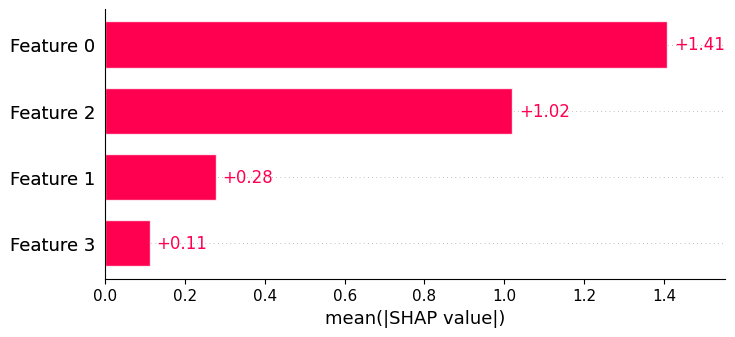

In [79]:
shap.plots.bar(vals)


In [80]:
#vibration_rms is most influential